# Регрессия: предсказание стоимости доставки

Бизнес-задача: понять, насколько дорогой будет доставка, чтобы решить, стоит ли предлагать компенсацию при опоздании. Если доставка дорогая, то компенсацию не предлагаем

Задача ML: предсказать стоимость доставки заказа (регрессия)

## Загрузка данных

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, PowerTransformer, OneHotEncoder, PolynomialFeatures
from sklearn.decomposition import PCA
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, max_error
from sklearn.model_selection import TimeSeriesSplit

from skopt import BayesSearchCV
from skopt.space import Integer, Real, Categorical

In [2]:
df = pd.read_csv('data/olist_enriched_clean.csv', parse_dates=['order_purchase_timestamp'])
df

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,seller_id,product_id,...,purchase_temp_avg_c,purchase_heavy_rain,delivery_precipitation_mm,delivery_temp_avg_c,delivery_heavy_rain,purchase_is_holiday,delivery_is_holiday,days_to_next_holiday,estimated_delivery_days,purchase_month
0,ec7a019261fce44180373d45b442d78f,c24fc5f9a446b4d8262041b9c64de772,delivered,2017-01-05 11:56:06,2017-01-05 12:10:17,2017-01-06 12:43:41,2017-01-11 13:14:05,2017-02-01,48efc9d94a9834137efd9ea76b065a38,f5d8f4fbc70ca2a0038b9a0010ed5cb0,...,24.1,0,13.9,23.6,0.0,0,0,666,26,2017-01
1,b95a0a8bd30aece4e94e81f0591249d8,ff3c6d35b4927c9b965aa6a68dcf56e4,delivered,2017-01-05 12:01:20,2017-01-07 03:35:37,2017-01-11 16:22:53,2017-01-17 15:38:58,2017-02-13,48efc9d94a9834137efd9ea76b065a38,6c04a068e5ab37749c980c42a036b9e3,...,24.1,0,13.4,22.5,0.0,0,0,666,38,2017-01
2,38bcb524e1c38c2c1b60600a80fc8999,d2c63ad286e3ca9dd69218008d61ff81,delivered,2017-01-05 12:06:36,2017-01-07 03:45:22,2017-01-11 15:35:54,2017-01-16 16:05:22,2017-02-13,48efc9d94a9834137efd9ea76b065a38,680cc8535be7cc69544238c1d6a83fe8,...,24.1,0,15.5,21.6,0.0,0,0,666,38,2017-01
3,7a18a504c1a4b32d883e68de2e1a7db0,e6bee29442c761ff0dfb9a4414922a5c,delivered,2017-01-05 12:09:08,2017-01-07 03:44:08,2017-01-11 15:35:53,2017-01-16 15:43:29,2017-02-13,48efc9d94a9834137efd9ea76b065a38,c0d4027067afcf9c1697cce981b8fed6,...,24.1,0,15.5,21.6,0.0,0,0,666,38,2017-01
4,6acecf438369055d9243e121045cca74,42d857e22f61f10476f0cda1aacc018a,delivered,2017-01-05 12:11:23,2017-01-07 03:44:07,2017-01-11 16:22:53,2017-01-17 16:06:30,2017-02-13,48efc9d94a9834137efd9ea76b065a38,1514ddb0f4a5afc8d24104e89c714403,...,24.1,0,13.4,22.5,0.0,0,0,666,38,2017-01
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
96198,52018484704db3661b98ce838612b507,e450a297a7bc6839ceb0cf1a2377fa02,delivered,2018-08-29 12:25:59,2018-08-29 12:35:17,2018-08-29 13:38:00,2018-08-30 22:48:27,2018-09-03,5f2684dab12e59f83bef73ae57724e45,777798445efd625458a90c13f3b3e6e7,...,18.0,0,0.0,19.8,0.0,0,0,65,4,2018-08
96199,0b223d92c27432930dfe407c6aea3041,e60df9449653a95af4549bbfcb18a6eb,delivered,2018-08-29 14:18:23,2018-08-29 14:31:07,2018-08-29 15:29:00,2018-08-30 16:24:55,2018-09-04,67bf6941ba2f1fa1d02c375766bc3e53,2b4472df15512a2825ae86fd9ae79335,...,17.7,0,0.0,19.4,0.0,0,0,65,5,2018-08
96200,168626408cb32af0ffaf76711caae1dc,6e353700bc7bcdf6ebc15d6de16d7002,delivered,2018-08-29 14:18:28,2018-08-29 14:30:23,2018-08-29 18:51:00,2018-08-30 16:52:31,2018-09-11,2a84855fd20af891be03bc5924d2b453,bdcf6a834e8faa30dac3886c7a58e92e,...,18.4,0,0.3,18.8,0.0,0,0,65,12,2018-08
96201,03ef5dedbe7492bdae72eec50764c43f,496630b6740bcca28fce9ba50d8a26ef,delivered,2018-08-29 14:52:00,2018-08-29 15:05:22,2018-08-29 20:01:00,2018-08-30 16:36:59,2018-09-03,7d7866a99a8656a42c7ff6352a433410,c7f27c5bef2338541c772b5776403e6a,...,18.0,0,0.0,19.8,0.0,0,0,65,4,2018-08


## EDA таргета

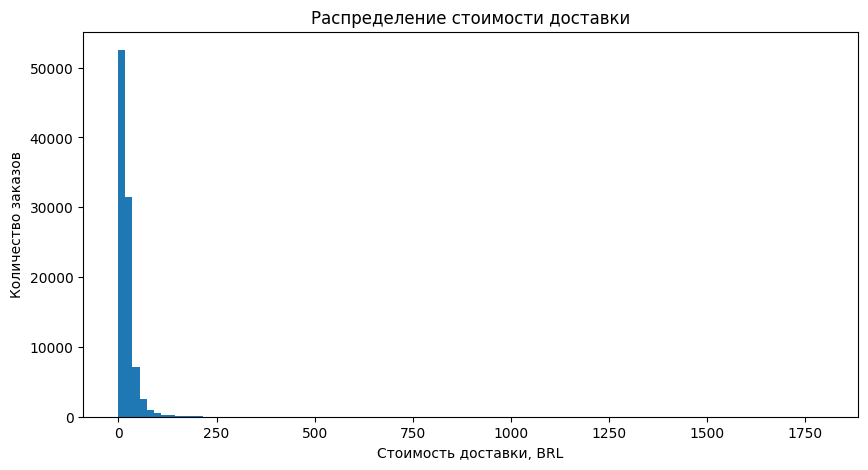

In [3]:
plt.figure(figsize=(10, 5))
plt.hist(df['total_freight'], bins=100)
plt.title('Распределение стоимости доставки')
plt.xlabel('Стоимость доставки, BRL')
plt.ylabel('Количество заказов')

plt.show()

In [4]:
df['total_freight'].describe().round(2)

count    96203.00
mean        22.78
std         21.57
min          0.00
25%         13.85
50%         17.17
75%         24.01
max       1794.96
Name: total_freight, dtype: float64

Распределение сильно скошено вправо, большинство заказов стоят 10-30 BRL, но есть выбросы до 1800 BRL. Применим log1p чтобы уменьшить влияние выбросов и сделать таргет более равномерным

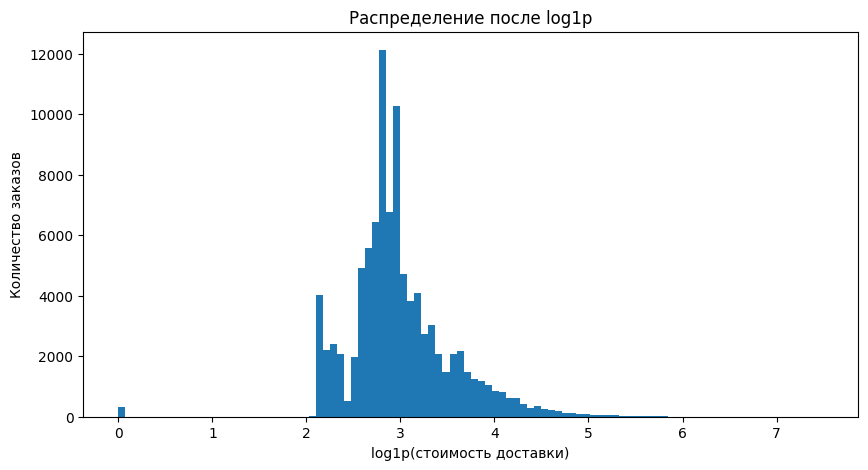

In [5]:
log_freight = np.log1p(df['total_freight'])

plt.figure(figsize=(10, 5))
plt.hist(log_freight, bins=100)
plt.title('Распределение после log1p')
plt.xlabel('log1p(стоимость доставки)')
plt.ylabel('Количество заказов')

plt.show()

In [6]:
log_freight.describe().round(2)

count    96203.00
mean         2.99
std          0.56
min          0.00
25%          2.70
50%          2.90
75%          3.22
max          7.49
Name: total_freight, dtype: float64

## Выбор признаков для обучения модели

Используем только признаки, известные до отправки заказа. Всё что появляется после (время доставки, погода при доставке, факт опоздания) исключаем

In [ ]:
num_features = [
    'product_weight_g',
    'product_volume_cm3',
    'product_length_cm',
    'product_height_cm',
    'product_width_cm',
    'n_items',
    'total_price',
    'avg_price',
    'payment_installments',
    'distance_km',
    'customer_hdi',
    'customer_gdp_per_capita',
    'customer_urban_pct',
    'seller_hdi',
    'seller_gdp_per_capita',
    'seller_urban_pct',
    'hdi_diff',
    'purchase_precipitation_mm',
    'purchase_temp_avg_c',
    'purchase_heavy_rain',
    'order_weekday',
    'order_month',
    'order_hour',
    'purchase_is_holiday',
    'days_to_next_holiday',
    'estimated_delivery_days',
]

cat_features = [
    'customer_state',
    'seller_state',
    'payment_type',
    'product_category_name_english',
]

all_features = num_features + cat_features
target = 'total_freight'

In [8]:
corr = df[num_features + [target]].corr()
corr

,product_weight_g,product_volume_cm3,product_length_cm,product_height_cm,product_width_cm,n_items,total_price,avg_price,payment_installments,distance_km,...,purchase_precipitation_mm,purchase_temp_avg_c,purchase_heavy_rain,order_weekday,order_month,order_hour,purchase_is_holiday,days_to_next_holiday,estimated_delivery_days,total_freight
product_weight_g,1.000000,0.802545,0.466620,0.580628,0.513798,-0.005273,0.331536,0.341646,0.197782,-0.008495,...,-0.001365,0.008184,0.001520,-0.000202,-0.007286,0.009846,0.003117,0.037112,0.075945,0.500009
product_volume_cm3,0.802545,1.000000,0.545263,0.723330,0.632217,0.002198,0.294942,0.303885,0.177684,-0.011998,...,-0.001001,0.001433,0.001338,0.003023,0.002453,0.010822,0.006548,0.059459,0.066211,0.481850
product_length_cm,0.466620,0.545263,1.000000,0.194239,0.549441,0.008992,0.144723,0.144681,0.124353,-0.004332,...,0.002987,-0.003274,0.001119,0.000924,-0.003698,0.008019,0.007111,0.061808,0.060556,0.258298
product_height_cm,0.580628,0.723330,0.194239,1.000000,0.287831,0.018394,0.227280,0.231907,0.136080,-0.000443,...,-0.004133,0.007661,-0.000715,0.003654,0.015095,0.006125,0.004764,0.032259,0.067424,0.333158
product_width_cm,0.513798,0.632217,0.549441,0.287831,1.000000,-0.004123,0.168505,0.173202,0.149143,-0.019868,...,-0.005420,-0.013242,-0.001814,0.004405,0.001273,0.010204,0.001458,0.066356,0.045162,0.263291
n_items,-0.005273,0.002198,0.008992,0.018394,-0.004123,1.000000,0.153554,-0.058591,0.067863,-0.016724,...,-0.001683,-0.006339,-0.002904,-0.011587,0.000074,-0.009740,-0.004060,-0.002690,0.015724,0.438989
total_price,0.331536,0.294942,0.144723,0.227280,0.168505,0.153554,1.000000,0.932982,0.313988,0.079934,...,0.004904,0.036828,0.003516,-0.002961,0.001907,0.004845,-0.002602,0.000837,0.077269,0.411164
avg_price,0.341646,0.303885,0.144681,0.231907,0.173202,-0.058591,0.932982,1.000000,0.316213,0.084202,...,0.004658,0.038935,0.003257,-0.000476,0.000724,0.008001,-0.001949,0.001965,0.074833,0.299229
payment_installments,0.197782,0.177684,0.124353,0.136080,0.149143,0.067863,0.313988,0.316213,1.000000,0.090949,...,-0.002944,0.032847,-0.002810,0.025494,0.030722,0.013411,0.007240,0.048343,0.093065,0.199233
distance_km,-0.008495,-0.011998,-0.004332,-0.000443,-0.019868,-0.016724,0.079934,0.084202,0.090949,1.000000,...,0.085756,0.449849,0.035400,0.009291,-0.000340,-0.002454,0.006858,0.044129,0.524238,0.314605


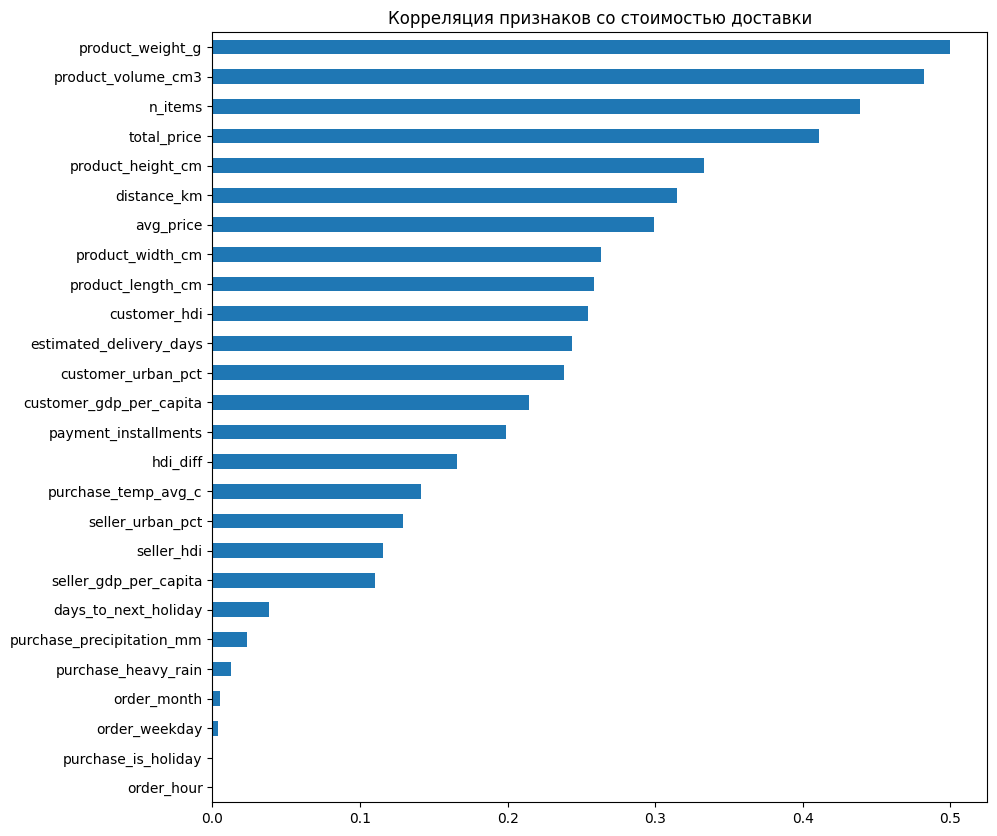

In [9]:
corr_res = corr[target].drop(target).abs().sort_values()

plt.figure(figsize=(10, 10))
corr_res.plot(kind='barh')
plt.title('Корреляция признаков со стоимостью доставки')

plt.show()

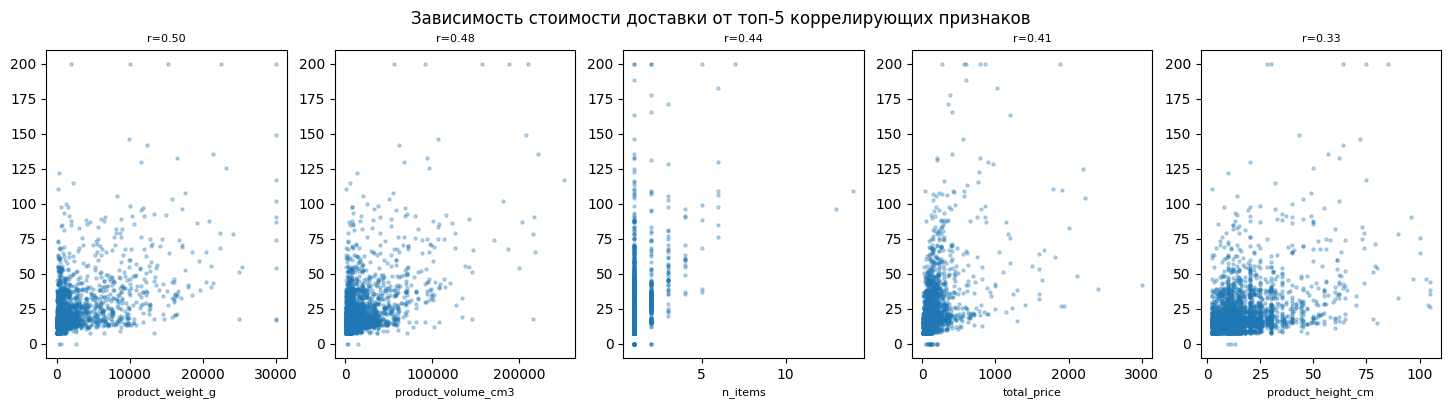

In [10]:
top5 = corr_res.abs().sort_values(ascending=False).head(5).index.tolist()

fig, axes = plt.subplots(1, 5, figsize=(18, 4))
for ax, feat in zip(axes, top5):
    sample = df[[feat, target]].dropna().sample(3000, random_state=42)
    ax.scatter(sample[feat], sample[target].clip(upper=200), alpha=0.3, s=5)
    ax.set_xlabel(feat, fontsize=8)
    ax.set_title(f'r={corr_res[feat]:.2f}', fontsize=8)

plt.suptitle('Зависимость стоимости доставки от топ-5 коррелирующих признаков')
plt.show()

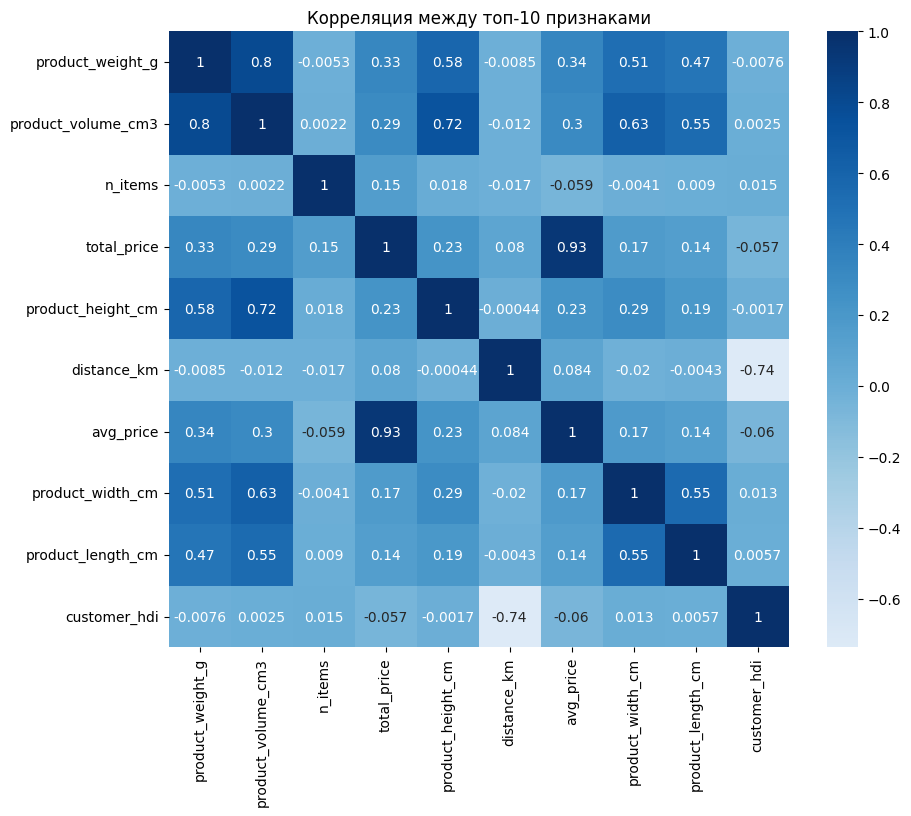

In [11]:
top_num = corr_res.abs().sort_values(ascending=False).head(10).index.tolist()
corr_matrix = df[top_num].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='Blues', center=0)
plt.title('Корреляция между топ-10 признаками')

plt.show()

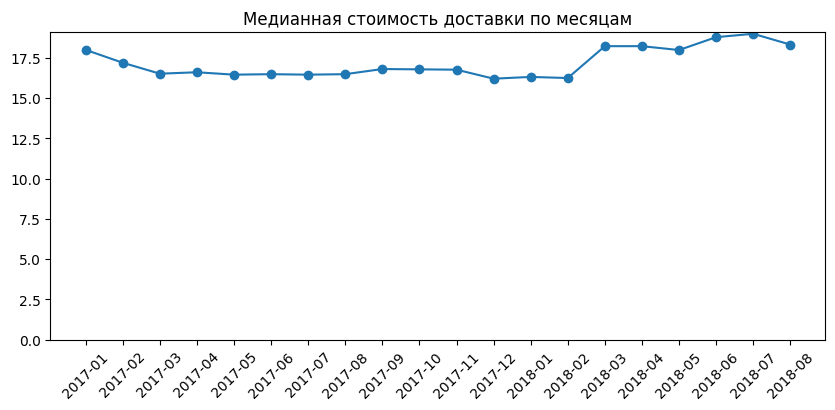

In [12]:
monthly = df.groupby('purchase_month')['total_freight'].median()

plt.figure(figsize=(10, 4))
plt.plot(monthly.index, monthly.values, marker='o')
plt.xticks(rotation=45)
plt.ylim(0)
plt.title('Медианная стоимость доставки по месяцам')

plt.show()

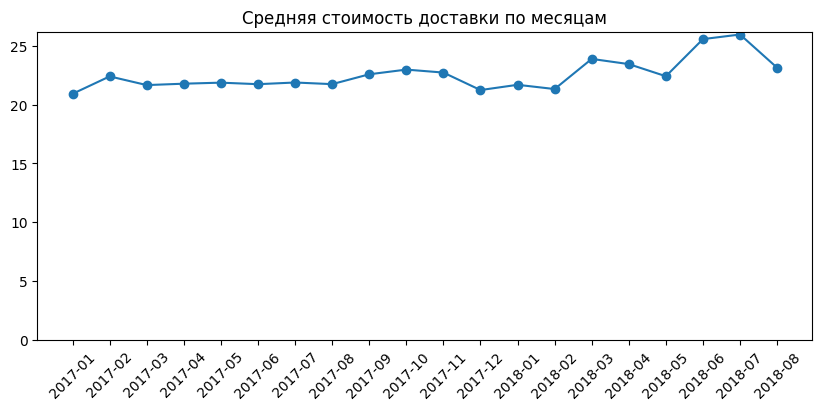

In [13]:
monthly = df.groupby('purchase_month')['total_freight'].mean()

plt.figure(figsize=(10, 4))
plt.plot(monthly.index, monthly.values, marker='o')
plt.xticks(rotation=45)
plt.ylim(0)
plt.title('Средняя стоимость доставки по месяцам')

plt.show()

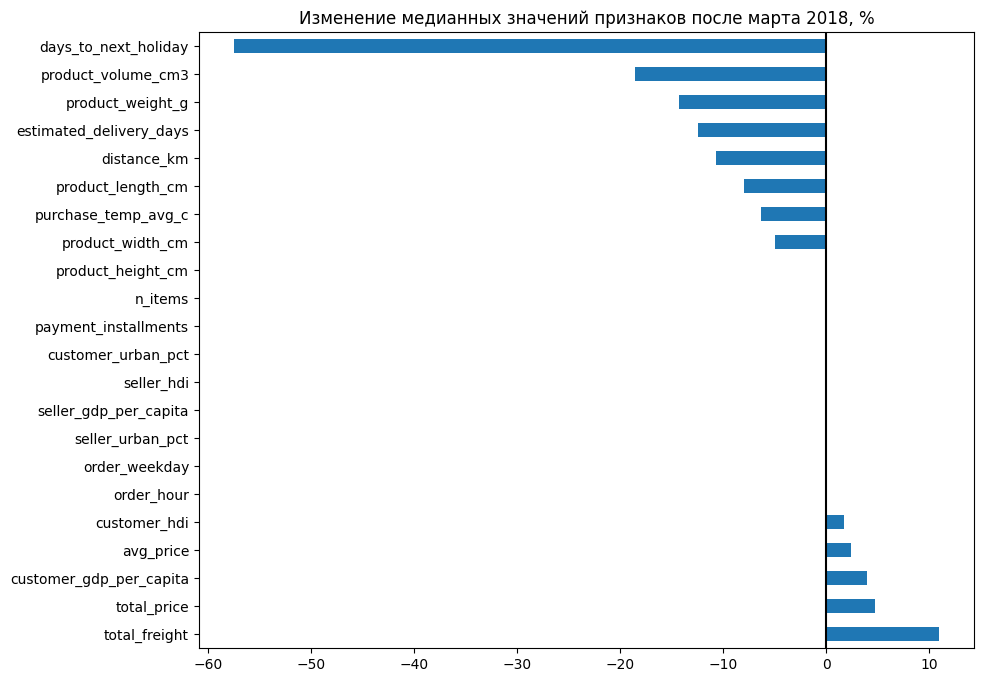

In [14]:
before = df[df['purchase_month'] <= '2018-02'][num_features + [target]].median()
after  = df[df['purchase_month'] >= '2018-03'][num_features + [target]].median()

change = ((after - before) / before * 100).round(1).sort_values(ascending=False)

drop_cols = ['hdi_diff', 'purchase_heavy_rain', 'purchase_is_holiday', 'purchase_precipitation_mm', 'order_month']
change_plot = change.drop(drop_cols).dropna()

plt.figure(figsize=(10, 8))
change_plot.plot(kind='barh')
plt.axvline(0, color='black')
plt.title('Изменение медианных значений признаков после марта 2018, %')

plt.show()

## Подготовка данных

In [15]:
df_before_new_tariff = df[df['purchase_month'] <= '2018-01']

X = df_before_new_tariff[all_features].copy()
y = df_before_new_tariff[target].copy()

split_idx = int(len(df_before_new_tariff) * 0.8)

X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

y_train_log = np.log1p(y_train)
y_test_log = np.log1p(y_test)

## Метрики качества

In [16]:
def evaluate(name, y_true, y_pred, results):
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    mape = np.mean(np.abs((y_true - y_pred) / y_true.clip(lower=1.0))) * 100
    max_err = max_error(y_true, y_pred)

    results.append({'Модель': name, 'MAE': mae, 'MSE': mse, 'RMSE': rmse, 'R2': r2, 'MAPE': mape, 'MAX_ERROR': max_err})
    print(f'{name} | MAE={mae:.2f}, MSE={mse:.2f}, RMSE={rmse:.2f}, R2={r2:.2f}, MAPE={mape:.2f}%, MAX_ERROR={max_err:.2f}')

results = []

## Модели

### Линейная регрессия (baseline)

In [17]:
num_pipe = Pipeline([
    ('imp', SimpleImputer(strategy='median')),
    ('pt', PowerTransformer(method='yeo-johnson')),
])
cat_pipe = Pipeline([
    ('imp', SimpleImputer(strategy='most_frequent')),
    ('ohe', OneHotEncoder(handle_unknown='ignore', sparse_output=False)),
])
preprocessor_lr = ColumnTransformer([
    ('num', num_pipe, num_features),
    ('cat', cat_pipe, cat_features),
])

lr_pipeline = Pipeline([
    ('prep', preprocessor_lr),
    ('pca', PCA(n_components=0.95, random_state=42)),
    ('model', LinearRegression()),
])

lr_pipeline.fit(X_train, y_train_log)
y_pred_lr = np.maximum(np.expm1(lr_pipeline.predict(X_test)), 0)

evaluate('Linear Regression (baseline)', y_test, y_pred_lr, results)

Linear Regression (baseline) | MAE=5.34, MSE=148.76, RMSE=12.20, R2=0.50, MAPE=19.54%, MAX_ERROR=336.77


### Линейная регрессия с полиномиальными признаками

In [18]:
num_pipe_poly = Pipeline([
    ('imp', SimpleImputer(strategy='median')),
    ('pt', PowerTransformer(method='yeo-johnson')),
    ('poly', PolynomialFeatures(degree=2, include_bias=False)),
    ('pca', PCA(n_components=0.95, random_state=42)),
])
cat_pipe = Pipeline([
    ('imp', SimpleImputer(strategy='most_frequent')),
    ('ohe', OneHotEncoder(handle_unknown='ignore', sparse_output=False)),
])
preprocessor_poly = ColumnTransformer([
    ('num', num_pipe_poly, num_features),
    ('cat', cat_pipe, cat_features),
])

lr_poly_pipeline = Pipeline([
    ('prep', preprocessor_poly),
    ('model', LinearRegression()),
])

lr_poly_pipeline.fit(X_train, y_train_log)
y_pred_lr_poly = np.maximum(np.expm1(lr_poly_pipeline.predict(X_test)), 0)

evaluate('Linear Regression + Poly', y_test, y_pred_lr_poly, results)

Linear Regression + Poly | MAE=4.58, MSE=105.97, RMSE=10.29, R2=0.65, MAPE=17.29%, MAX_ERROR=241.72


### Случайный лес

In [19]:
# для деревьев скейлер не нужен, просто импутация
preprocessor_rf = ColumnTransformer([
    ('num', SimpleImputer(strategy='median'), num_features),
    ('cat', Pipeline([
        ('imp', SimpleImputer(strategy='most_frequent')),
        ('ohe', OneHotEncoder(handle_unknown='ignore', sparse_output=False)),
    ]), cat_features),
])

rf_search = BayesSearchCV(
    Pipeline([('prep', preprocessor_rf), ('model', RandomForestRegressor(random_state=42, n_jobs=-1))]),
    search_spaces={
        'model__n_estimators': Integer(100, 300),
        'model__max_depth': Integer(3, 15),
        'model__max_features': Categorical(['sqrt', 'log2']),
        'model__min_samples_leaf': Integer(1, 10),
    },
    n_iter=15, cv=TimeSeriesSplit(n_splits=3), scoring='neg_root_mean_squared_error', random_state=42, n_jobs=-1
)

rf_search.fit(X_train, y_train_log)
rf_best = rf_search.best_estimator_
y_pred_rf = np.maximum(np.expm1(rf_best.predict(X_test)), 0)

evaluate('Random Forest', y_test, y_pred_rf, results)

Random Forest | MAE=3.98, MSE=106.37, RMSE=10.31, R2=0.65, MAPE=14.25%, MAX_ERROR=324.76


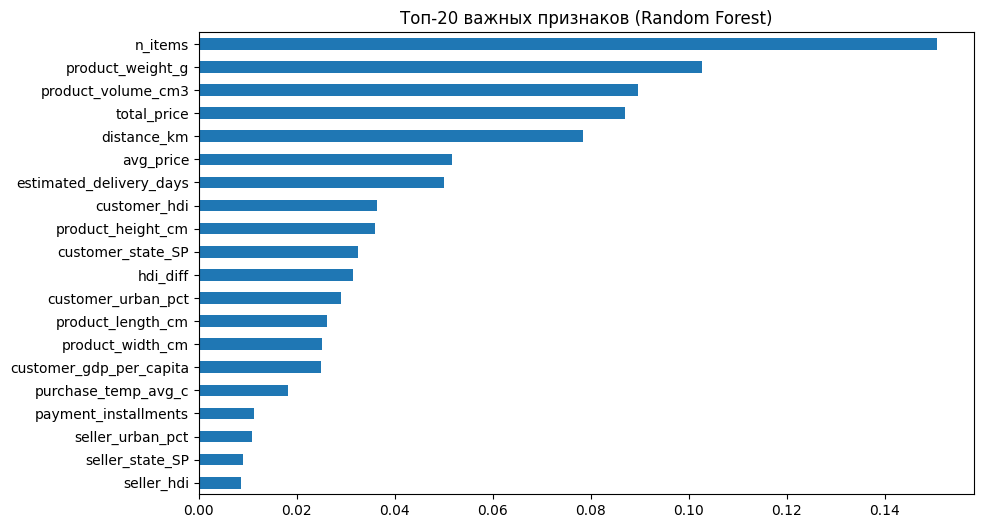

In [20]:
ohe_names = rf_best['prep'].named_transformers_['cat']['ohe'].get_feature_names_out(cat_features)
feature_names = num_features + list(ohe_names)

importances = pd.Series(rf_best['model'].feature_importances_, index=feature_names)

plt.figure(figsize=(10, 6))
importances.nlargest(20).sort_values().plot(kind='barh')
plt.title('Топ-20 важных признаков (Random Forest)')

plt.show()

### Градиентный бустинг

In [21]:
preprocessor_gb = ColumnTransformer([
    ('num', SimpleImputer(strategy='median'), num_features),
    ('cat', Pipeline([
        ('imp', SimpleImputer(strategy='most_frequent')),
        ('ohe', OneHotEncoder(handle_unknown='ignore', sparse_output=False)),
    ]), cat_features),
])

gb_search = BayesSearchCV(
    Pipeline([('prep', preprocessor_gb), ('model', HistGradientBoostingRegressor(random_state=42, early_stopping=True, max_iter=500))]),
    search_spaces={
        'model__max_depth': Integer(3, 10),
        'model__learning_rate': Real(0.01, 0.3, prior='log-uniform'),
        'model__l2_regularization': Real(1e-4, 1.0, prior='log-uniform'),
        'model__min_samples_leaf': Integer(10, 50),
    },
    n_iter=20, cv=TimeSeriesSplit(n_splits=3), scoring='neg_root_mean_squared_error', random_state=42, n_jobs=-1
)

gb_search.fit(X_train, y_train_log)
gb_best = gb_search.best_estimator_
y_pred_gb = np.maximum(np.expm1(gb_best.predict(X_test)), 0)

evaluate('Gradient Boosting', y_test, y_pred_gb, results)

/Users/nvlkarakotova/Library/Python/3.9/lib/python/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


Gradient Boosting | MAE=3.20, MSE=76.51, RMSE=8.75, R2=0.75, MAPE=10.61%, MAX_ERROR=277.30


### Нейронка (MLP)

In [22]:
num_pipe_mlp = Pipeline([
    ('imp', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()),
])
preprocessor_mlp = ColumnTransformer([
    ('num', num_pipe_mlp, num_features),
    ('cat', Pipeline([
        ('imp', SimpleImputer(strategy='most_frequent')),
        ('ohe', OneHotEncoder(handle_unknown='ignore', sparse_output=False)),
    ]), cat_features),
])

mlp_search = BayesSearchCV(
    Pipeline([('prep', preprocessor_mlp), ('model', MLPRegressor(max_iter=500, early_stopping=True, random_state=42))]),
    search_spaces={
        'model__activation': Categorical(['relu', 'tanh']),
        'model__alpha': Real(1e-5, 1e-1, prior='log-uniform'),
        'model__learning_rate_init': Real(1e-4, 1e-2, prior='log-uniform'),
    },
    n_iter=20, cv=TimeSeriesSplit(n_splits=3), scoring='neg_root_mean_squared_error', random_state=42, n_jobs=-1
)

mlp_search.fit(X_train, y_train_log)
mlp_best = mlp_search.best_estimator_
y_pred_mlp = np.maximum(np.expm1(mlp_best.predict(X_test)), 0)

evaluate('MLP', y_test, y_pred_mlp, results)

MLP | MAE=3.84, MSE=68.13, RMSE=8.25, R2=0.77, MAPE=15.84%, MAX_ERROR=160.06


## Сравнение моделей

In [23]:
results_df = pd.DataFrame(results).set_index('Модель')
results_df = results_df.round({'MAE': 2, 'MSE': 1, 'RMSE': 2, 'R2': 3, 'MAPE': 1, 'MAX_ERROR': 1})
results_df = results_df.sort_values('RMSE')

display(results_df.style.highlight_min(subset=['MAE', 'MSE', 'RMSE', 'MAPE', 'MAX_ERROR'], color='lightgreen').highlight_max(subset=['R2'], color='lightgreen'))

,MAE,MSE,RMSE,R2,MAPE,MAX_ERROR
Модель,,,,,,
MLP,3.840000,68.100000,8.250000,0.773000,15.800000,160.100000
Gradient Boosting,3.200000,76.500000,8.750000,0.745000,10.600000,277.300000
Linear Regression + Poly,4.580000,106.000000,10.290000,0.647000,17.300000,241.700000
Random Forest,3.980000,106.400000,10.310000,0.646000,14.200000,324.800000
Linear Regression (baseline),5.340000,148.800000,12.200000,0.504000,19.500000,336.800000


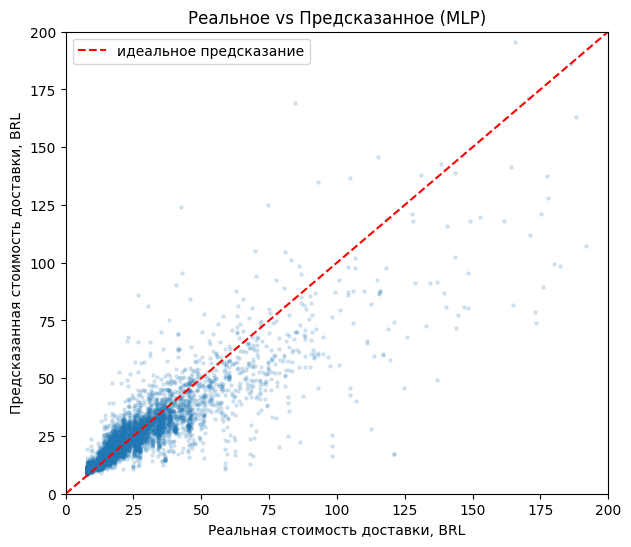

In [24]:
plt.figure(figsize=(7, 6))
plt.scatter(y_test, y_pred_mlp, alpha=0.15, s=5)
plt.plot([0, 200], [0, 200], 'r--', linewidth=1.5, label='идеальное предсказание')
plt.xlabel('Реальная стоимость доставки, BRL')
plt.ylabel('Предсказанная стоимость доставки, BRL')
plt.title('Реальное vs Предсказанное (MLP)')
plt.xlim(0, 200)
plt.ylim(0, 200)
plt.legend()

plt.show()

## Работа с повышением цен

In [25]:
calib_mask = (df['order_purchase_timestamp'] >= '2018-03-01') & (df['order_purchase_timestamp'] < '2018-03-15')
test_mask  =  df['order_purchase_timestamp'] >= '2018-03-15'

X_cal = df.loc[calib_mask, all_features]
y_cal = df.loc[calib_mask, target]
X_te  = df.loc[test_mask, all_features]
y_te  = df.loc[test_mask, target]

y_cal_pred = np.maximum(np.expm1(mlp_best.predict(X_cal)), 0.1)
ratio_med = np.median(y_cal.values / y_cal_pred)
ratio_mea = np.mean(y_cal.values / y_cal_pred)

print(f'ratio_med: {ratio_med:.2f}')
print(f'ratio_mea: {ratio_mea:.2f}')

y_te_pred = np.maximum(np.expm1(mlp_best.predict(X_te)), 0)
y_te_corrected_med = y_te_pred * ratio_med
y_te_corrected_mea = y_te_pred * ratio_mea

results_drift = []

evaluate('MLP без поправки', y_te, y_te_pred, results_drift)
evaluate('MLP + поправка (медиана)', y_te, y_te_corrected_med, results_drift)
evaluate('MLP + поправка (среднее)', y_te, y_te_corrected_mea, results_drift)

ratio_med: 1.03
ratio_mea: 1.07
MLP без поправки | MAE=6.24, MSE=240.39, RMSE=15.50, R2=0.60, MAPE=38.86%, MAX_ERROR=1359.27
MLP + поправка (медиана) | MAE=6.16, MSE=233.23, RMSE=15.27, R2=0.61, MAPE=39.58%, MAX_ERROR=1348.20
MLP + поправка (среднее) | MAE=6.10, MSE=221.95, RMSE=14.90, R2=0.63, MAPE=41.52%, MAX_ERROR=1327.31


In [26]:
drift_df = pd.DataFrame(results_drift).set_index('Модель')
drift_df = drift_df.round({'MAE': 2, 'MSE': 1, 'RMSE': 2, 'R2': 3, 'MAPE': 1, 'MAX_ERROR': 1})
drift_df = drift_df.sort_values('RMSE')

display(drift_df.style.highlight_min(subset=['MAE', 'MSE', 'RMSE', 'MAPE', 'MAX_ERROR'], color='lightgreen').highlight_max(subset=['R2'], color='lightgreen'))

,MAE,MSE,RMSE,R2,MAPE,MAX_ERROR
Модель,,,,,,
MLP + поправка (среднее),6.100000,222.000000,14.900000,0.629000,41.500000,1327.300000
MLP + поправка (медиана),6.160000,233.200000,15.270000,0.611000,39.600000,1348.200000
MLP без поправки,6.240000,240.400000,15.500000,0.599000,38.900000,1359.300000


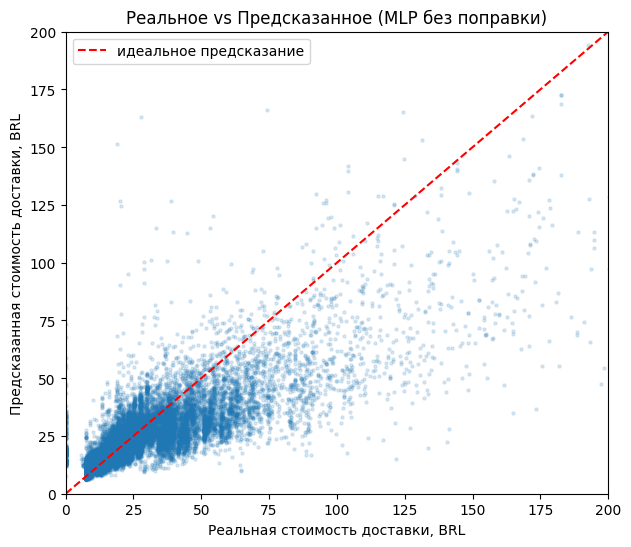

In [27]:
plt.figure(figsize=(7, 6))
plt.scatter(y_te, y_te_pred, alpha=0.15, s=5)
plt.plot([0, 200], [0, 200], 'r--', linewidth=1.5, label='идеальное предсказание')
plt.xlabel('Реальная стоимость доставки, BRL')
plt.ylabel('Предсказанная стоимость доставки, BRL')
plt.title('Реальное vs Предсказанное (MLP без поправки)')
plt.xlim(0, 200)
plt.ylim(0, 200)
plt.legend()

plt.show()

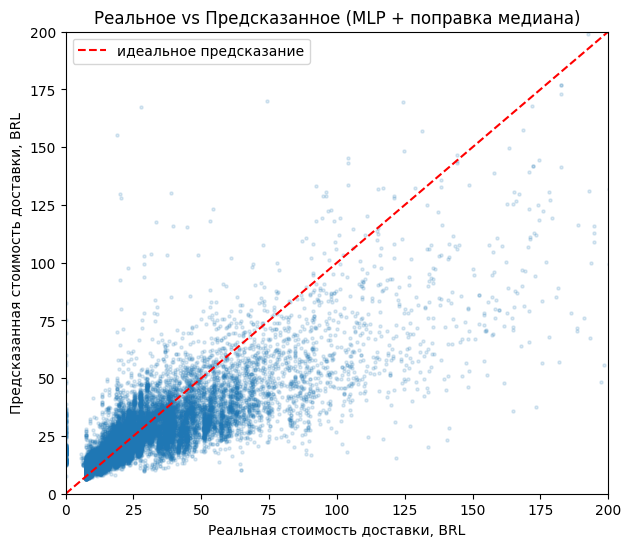

In [28]:
plt.figure(figsize=(7, 6))
plt.scatter(y_te, y_te_corrected_med, alpha=0.15, s=5)
plt.plot([0, 200], [0, 200], 'r--', linewidth=1.5, label='идеальное предсказание')
plt.xlabel('Реальная стоимость доставки, BRL')
plt.ylabel('Предсказанная стоимость доставки, BRL')
plt.title('Реальное vs Предсказанное (MLP + поправка медиана)')
plt.xlim(0, 200)
plt.ylim(0, 200)
plt.legend()

plt.show()

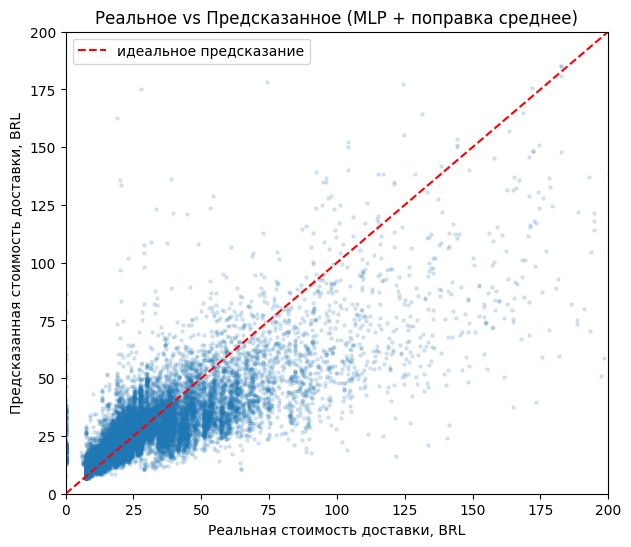

In [36]:
plt.figure(figsize=(7, 6))
plt.scatter(y_te, y_te_corrected_mea, alpha=0.15, s=5)
plt.plot([0, 200], [0, 200], 'r--', linewidth=1.5, label='идеальное предсказание')
plt.xlabel('Реальная стоимость доставки, BRL')
plt.ylabel('Предсказанная стоимость доставки, BRL')
plt.title('Реальное vs Предсказанное (MLP + поправка среднее)')
plt.xlim(0, 200)
plt.ylim(0, 200)
plt.legend()

plt.show()